# 02 · Measured improvement, remaining errors, and your own export

**Result:** landing-aware residual ridge improves coordinate RMSE from **0.9896 to 0.9269 yards**
on the same **32 validation games and 67,857 player-frames**. The later holdout is unscored.
This is a reproducible development result—not a Kaggle leaderboard score or a state-of-the-art claim.

The notebook validates saved evidence, renders the comparison, examines failure slices, and records
the next modeling decision. It does not silently retrain or generate a submission.

In [1]:
import base64
import os
import subprocess
import sys
from pathlib import Path

from IPython.display import HTML, Image, Markdown, display

from nfl_trajectory.analysis import (
    budget_figure,
    comparison,
    error_budget,
    experiment_figure,
    figure_png,
    load_evidence,
)
from nfl_trajectory.runtime import Run

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/nfl_trajectory").is_dir())
with Run(ROOT, "notebook_evaluation") as run:
    evidence, selection_audit, evidence_label = load_evidence(ROOT)
    scores = comparison(evidence)
    run.event(
        "evaluation_verified",
        source=evidence_label,
        selected_model=evidence["selected_model"],
        rows=evidence["validation_rows_per_model"],
    )
display(Markdown(f"**Evidence:** {evidence_label}. **Holdout:** not evaluated."))

{"timestamp": "2026-09-08T00:40:41.201+00:00", "run_id": "20260908T004041Z-f4c93b6d", "event": "started", "elapsed_seconds": 0.0, "command": "notebook_evaluation"}
{"timestamp": "2026-09-08T00:40:41.205+00:00", "run_id": "20260908T004041Z-f4c93b6d", "event": "evaluation_verified", "elapsed_seconds": 0.004, "source": "Verified published experiment", "selected_model": "landing_ridge", "rows": 67857}
{"timestamp": "2026-09-08T00:40:41.205+00:00", "run_id": "20260908T004041Z-f4c93b6d", "event": "completed", "elapsed_seconds": 0.004, "error_type": null}


**Evidence:** Verified published experiment. **Holdout:** not evaluated.

## Score the same coordinates, not a different problem

$$\mathrm{RMSE}=\sqrt{\frac{\sum_i[(\hat{x}_i-x_i)^2+(\hat{y}_i-y_i)^2]}{2N}}.$$

Every coordinate/frame receives equal weight. ADE is frame-weighted Euclidean distance; FDE is
trajectory-weighted final displacement. The 95th percentile describes the error tail. These
complement the official metric; neither classification metrics nor an average of game RMSEs replaces it.

,model,RMSE / yd,Frame ADE / yd,Trajectory FDE / yd,p95 / yd,Selected features,RMSE reduction vs baseline / %
0,landing_ridge,0.9269,0.8254,1.4168,2.7538,64,6.3361
1,interaction_ridge,0.9422,0.8438,1.4309,2.8081,64,4.7870
2,motion_ridge,0.9467,0.8545,1.4686,2.8071,64,4.3281
3,role_ridge,0.9896,0.8847,1.5057,3.0028,6,0.0000
4,constant_velocity,1.7225,1.5142,2.8696,5.4431,1,-74.0674


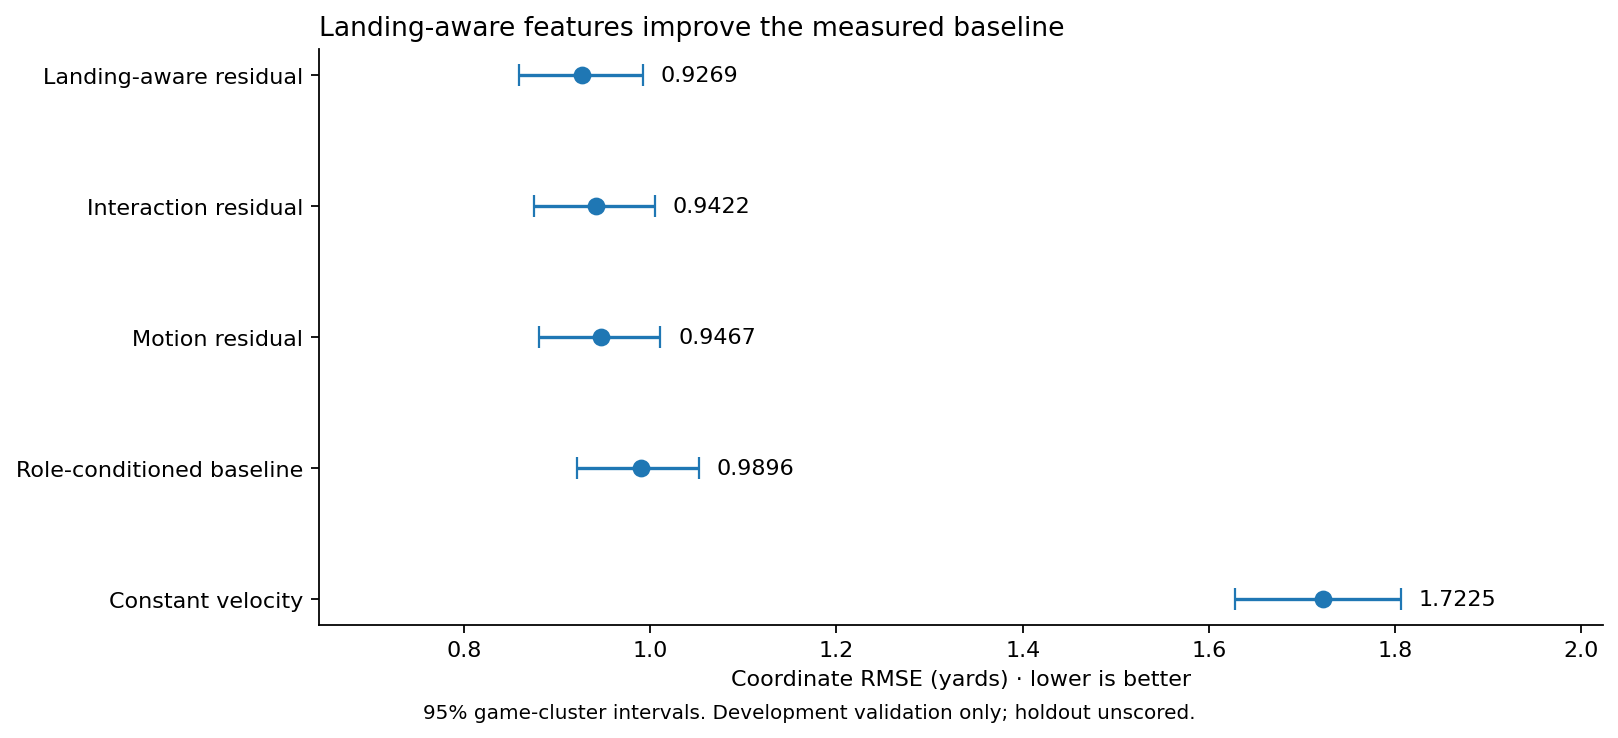

In [2]:
columns = [
    "model",
    "coordinate_rmse_yards",
    "ade_frame_weighted_yards",
    "fde_trajectory_weighted_yards",
    "p95_displacement_yards",
    "selected_features",
    "rmse_reduction_vs_baseline_percent",
]
display(
    scores[columns]
    .rename(
        columns={
            "coordinate_rmse_yards": "RMSE / yd",
            "ade_frame_weighted_yards": "Frame ADE / yd",
            "fde_trajectory_weighted_yards": "Trajectory FDE / yd",
            "p95_displacement_yards": "p95 / yd",
            "selected_features": "Selected features",
            "rmse_reduction_vs_baseline_percent": "RMSE reduction vs baseline / %",
        }
    )
    .round(4)
)
display(Image(data=figure_png(experiment_figure(evidence))))

In [3]:
best = scores.iloc[0]
paired = best["delta_vs_role_ridge_ci95"]
display(
    Markdown(
        f"**Selected development candidate:** `{best['model']}`. "
        f"**RMSE reduction:** {best['rmse_reduction_vs_baseline_percent']:.2f}% versus role ridge; "
        f"{evidence['improvement_vs_velocity_percent']:.2f}% versus constant velocity. "
        f"**Paired 95% difference vs role ridge:** [{paired[0]:.4f}, {paired[1]:.4f}] yards."
    )
)

**Selected development candidate:** `landing_ridge`. **RMSE reduction:** 6.34% versus role ridge; 46.19% versus constant velocity. **Paired 95% difference vs role ridge:** [-0.0829, -0.0434] yards.

The paired interval resamples entire games with the same sampled game indices for both models.
Its negative values favor the landing-aware challenger on these validation games. It is not adjusted
for repeated model selection and does not establish generalization to a new season. The recorded
summary does not contain a paired landing-versus-interaction interval; overlapping marginal intervals
must not be treated as that test.

## Prioritize errors by their contribution to the objective

A slice contributes `2 × frames × RMSE²` to total squared error. The following calculations reconcile
back to the pooled metric. They identify where improvements would matter most under the actual score.

,value,rows,coordinate_rmse_yards,frame_share_percent,squared_error_share_percent
0,Defensive Coverage,48729,1.032,71.811,89.048
1,Targeted Receiver,19128,0.578,28.189,10.952


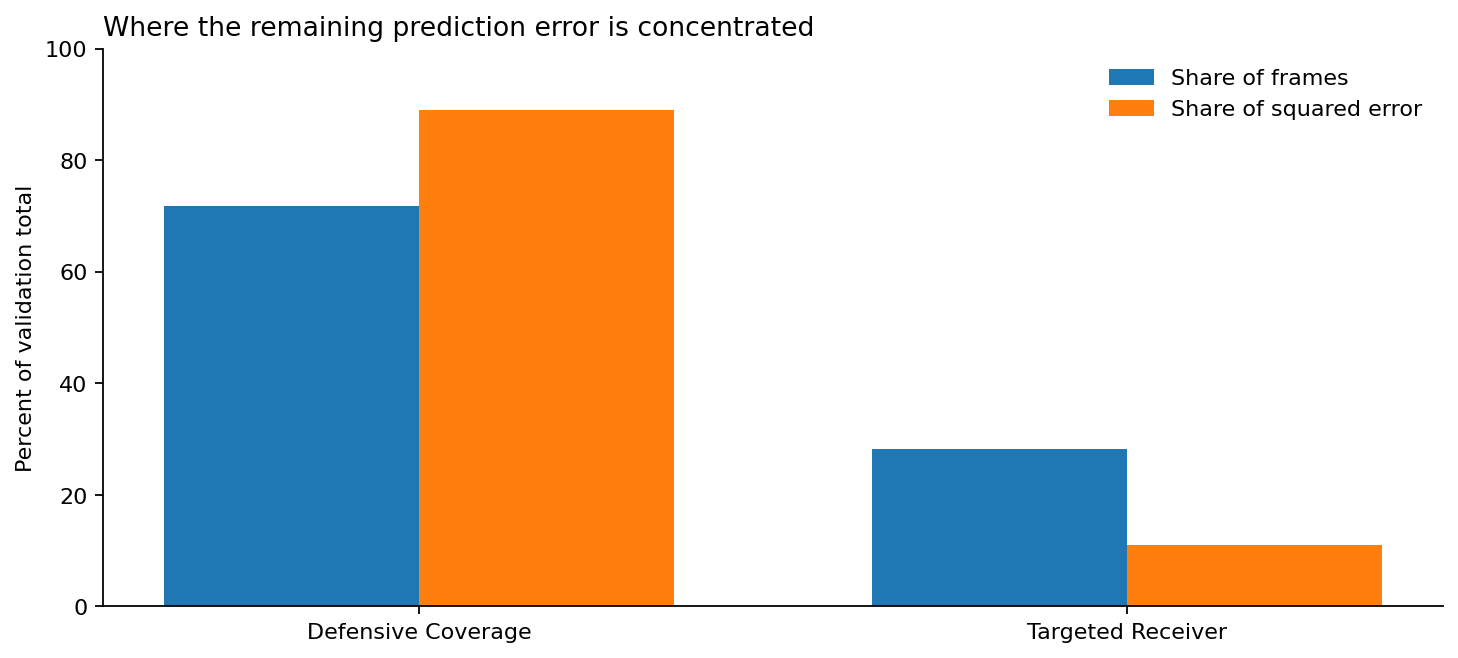

In [4]:
role_budget = error_budget(evidence, "role")
display(
    role_budget[
        [
            "value",
            "rows",
            "coordinate_rmse_yards",
            "frame_share_percent",
            "squared_error_share_percent",
        ]
    ].round(3)
)
display(Image(data=figure_png(budget_figure(evidence, "role"))))

,value,rows,coordinate_rmse_yards,frame_share_percent,squared_error_share_percent
0,1,49613,0.439,73.114,16.426
1,2,15009,1.325,22.119,45.197
2,3,3108,2.563,4.580,35.019
3,4,127,3.926,0.187,3.358


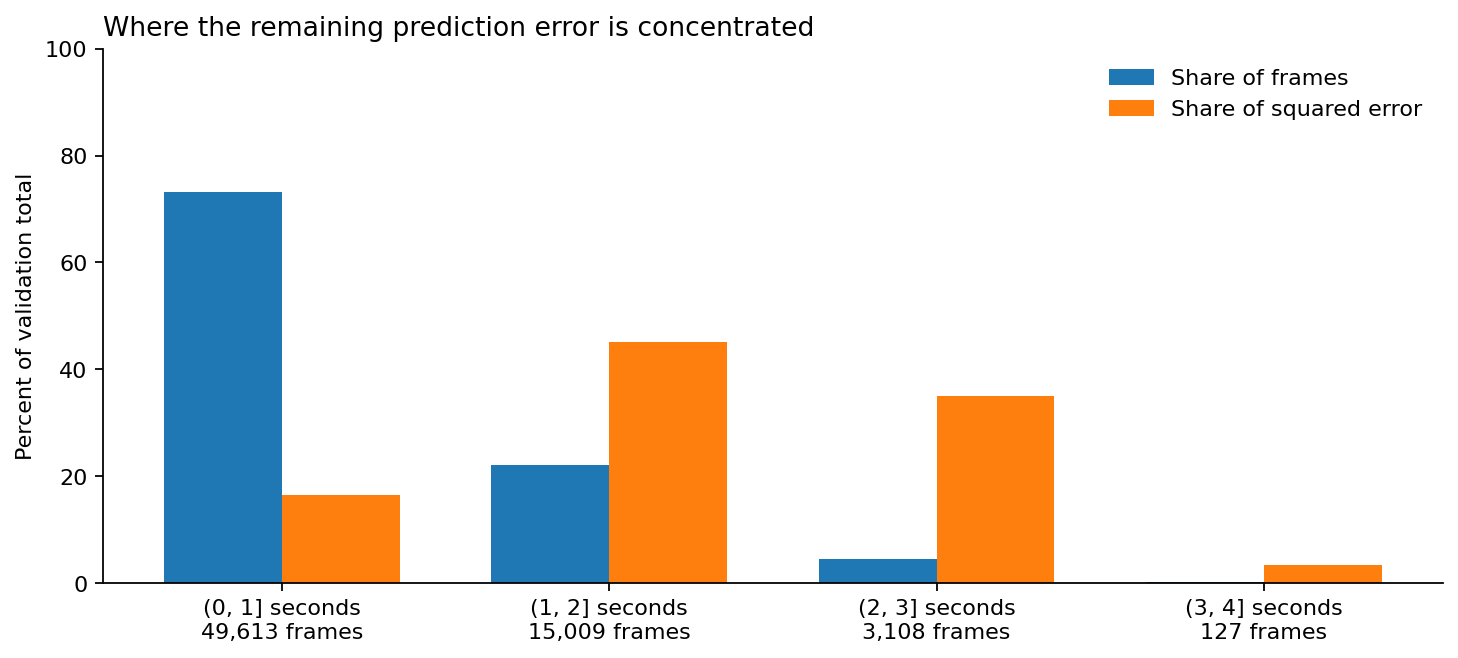

Forecasts beyond one second are **26.9% of frames** but **83.6% of squared error**. The final bucket has only 127 frames; do not draw a conclusion from that bucket alone.

In [5]:
time_budget = error_budget(evidence, "forecast_second")
display(
    time_budget[
        [
            "value",
            "rows",
            "coordinate_rmse_yards",
            "frame_share_percent",
            "squared_error_share_percent",
        ]
    ].round(3)
)
display(Image(data=figure_png(budget_figure(evidence, "forecast_second"))))
longer = time_budget.loc[time_budget.value.astype(int) > 1]
display(
    Markdown(
        f"Forecasts beyond one second are **{longer.frame_share_percent.sum():.1f}% of frames** "
        f"but **{longer.squared_error_share_percent.sum():.1f}% of squared error**. "
        "The final bucket has only 127 frames; do not draw a conclusion from that bucket alone."
    )
)

## Decision and stopping conditions

**Keep `landing_ridge` as the measured champion.** Defensive coverage contributes about 89% of its
remaining squared error. Prioritize role-aware, nonlinear landing-relative dynamics and temporal
interaction modeling, especially beyond one second.

The larger interaction candidate did not win. It displaced 23 of the landing model's selected columns,
so the result is not proof that interaction information is useless. Notebook 01 records the protected
feature-block and forward-chaining validation experiment needed to test that question correctly.

Do not unlock the holdout until feature selection and model choices are frozen. A stronger architecture
is a research hypothesis until the same evaluation protocol demonstrates improvement. No new neural
model or held-out-season score is claimed in this report.

## Create and download your own inference notebook

This is a **code competition**: export an inference notebook that implements the organizer's API,
not a fabricated hidden-test CSV. The cell below uses your completed local model and verifies its
source hashes, baseline, split, and completion receipt before export.

Leave `CREATE_SUBMISSION = False` to read or rerender the research. To create your file, set it to
`True` and run this cell yourself in the existing project kernel. A download link appears after
successful creation. No Kaggle credentials are requested, and no submission API is called.

Run the downloaded notebook yourself on Kaggle with the competition input attached. It runs the
organizer's local gateway and uses per-play verified checkpoints when the working directory is retained.
A new cloud session needs saved outputs restored to reuse that disk state. The official gateway and
hidden evaluation have **not** been executed as part of this published research. You decide whether
and when to use Kaggle's submission interface; late-submission availability must be checked in your account.

In [6]:
CREATE_SUBMISSION = False
if CREATE_SUBMISSION and os.getenv("NFL_NOTEBOOK_AUTORUN") != "1":
    output = ROOT / "artifacts/kaggle/submission.ipynb"
    with Run(ROOT, "notebook_export") as run:
        subprocess.run(
            [sys.executable, str(ROOT / "kaggle/export.py"), "--model", evidence["selected_model"]],
            cwd=ROOT,
            check=True,
        )
        if not output.is_file():
            raise FileNotFoundError("The verified export did not create its expected output.")
        payload = base64.b64encode(output.read_bytes()).decode("ascii")
        display(
            HTML(
                '<a download="submission.ipynb" href="data:application/octet-stream;base64,'
                + payload
                + '">Download your generated inference notebook</a>'
            )
        )
        run.event(
            "user_download_ready",
            model=evidence["selected_model"],
            path="artifacts/kaggle/submission.ipynb",
            submission_status="not_submitted",
        )
else:
    display(
        Markdown(
            "**Creation is off.** Set `CREATE_SUBMISSION = True` and run this cell yourself. "
            "Automated notebook publication never performs this opt-in action."
        )
    )

**Creation is off.** Set `CREATE_SUBMISSION = True` and run this cell yourself. Automated notebook publication never performs this opt-in action.